# **Handling data using Pandas**

## **Missing Values**

In Pandas, missing data occurs when some values are missing or not collected properly and these missing values are represented as:

1. **None:** A Python object used to represent missing values in object-type arrays.

2. **NaN:** A special floating-point value from NumPy which is recognized by all systems that use IEEE floating-point standards.



**Checking Missing values**

Pandas provides two important functions which help in detecting whether a value is NaN helpful in making data cleaning and preprocessing easier in a DataFrame or Series are given below :

**1. Using isnull():**

isnull() returns a DataFrame of Boolean value where True represents missing data (NaN). This is simple if we want to find and fill missing data in a dataset.

In [2]:
# Finding Missing Values in a DataFrame
import pandas as pd
import numpy as np

d = {'First Score': [100, 90, np.nan, 95],
        'Second Score': [30, 45, 56, np.nan],
        'Third Score': [np.nan, 40, 80, 98]}
df = pd.DataFrame(d)

mv = df.isnull()

print(mv)

   First Score  Second Score  Third Score
0        False         False         True
1        False         False        False
2         True         False        False
3        False          True        False


**2. Using isna()**

isna() returns a DataFrame of Boolean values where True indicates missing data (NaN). It is used to detect missing values just like isnull().

In [3]:
import pandas as pd
import numpy as np

data = {'Name': ['Amit', 'Sita', np.nan, 'Raj'],
        'Age': [25, np.nan, 22, 28]}

df = pd.DataFrame(data)

# Check for missing values using isna()
print(df.isna())

    Name    Age
0  False  False
1  False   True
2   True  False
3  False  False


**Handling Missing Values**

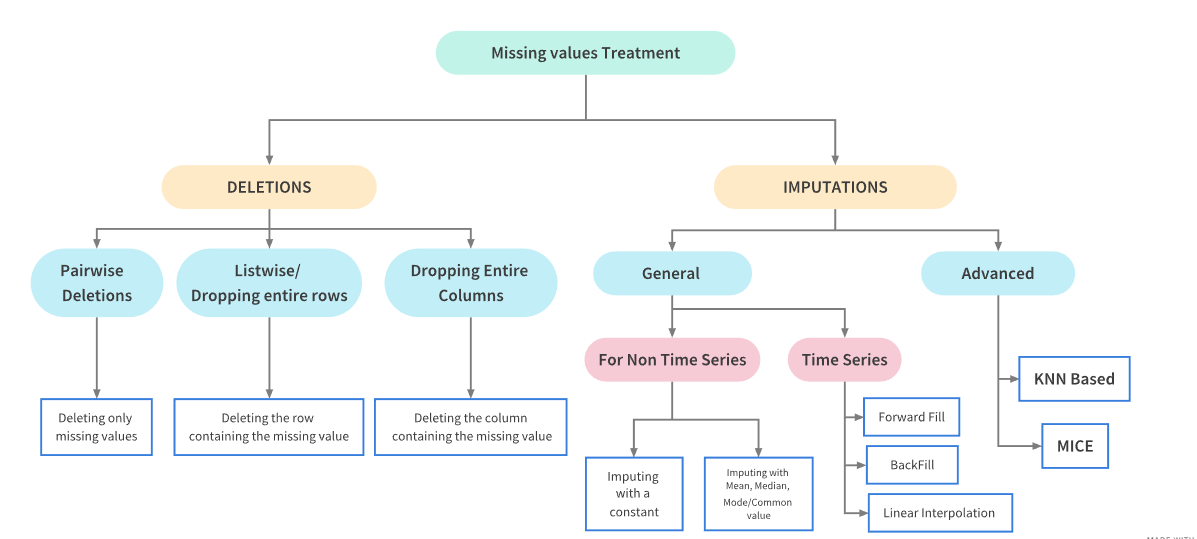

In [6]:
import pandas as pd

df = pd.read_csv('employees.csv')

In [7]:
df.head()

,First Name,Gender,Start Date,Last Login Time,Salary,Bonus %,Senior Management,Team
0,Douglas,Male,8/6/1993,12:42 PM,97308,6.945,True,Marketing
1,Thomas,Male,3/31/1996,6:53 AM,61933,4.170,True,NaN
2,Maria,Female,4/23/1993,11:17 AM,130590,11.858,False,Finance
3,Jerry,Male,3/4/2005,1:00 PM,138705,9.340,True,Finance
4,Larry,Male,1/24/1998,4:47 PM,101004,1.389,True,Client Services


In [9]:
df.isnull().sum()

First Name            67
Gender               145
Start Date             0
Last Login Time        0
Salary                 0
Bonus %                0
Senior Management     67
Team                  43
dtype: int64

### **Deletion**

The dropna() function used to removes rows or columns with NaN values. It can be used to drop data based on different conditions.

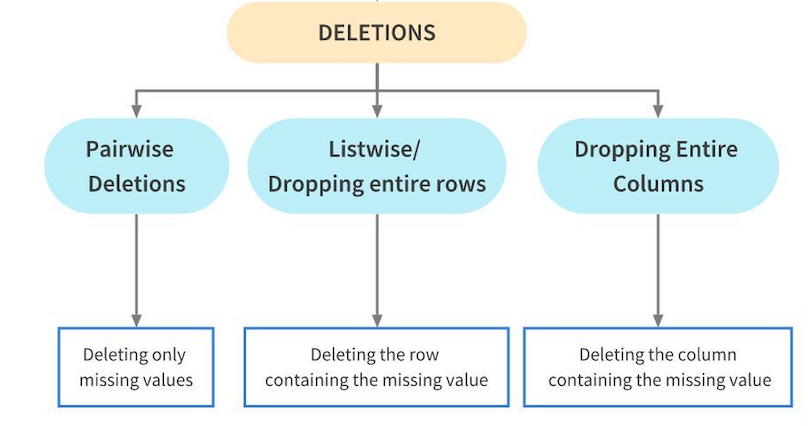

**Dropping Rows with At Least One Null Value (Pairwise Deletions)**

Remove rows that contain at least one missing value.

In [10]:
import pandas as pd
import numpy as np

dict = {'First Score': [100, 90, np.nan, 95],
        'Second Score': [30, np.nan, 45, 56],
        'Third Score': [52, 40, 80, 98],
        'Fourth Score': [np.nan, np.nan, np.nan, 65]}
df = pd.DataFrame(dict)

df.dropna()

,First Score,Second Score,Third Score,Fourth Score
3,95.0,56.0,98,65.0


**Dropping Rows with All Null Values (Listwise)**

We can drop rows where all values are missing using dropna(how='all').

In [11]:
dict = {'First Score': [100, np.nan, np.nan, 95],
        'Second Score': [30, np.nan, 45, 56],
        'Third Score': [52, np.nan, 80, 98],
        'Fourth Score': [np.nan, np.nan, np.nan, 65]}
df = pd.DataFrame(dict)

df.dropna(how='all')

,First Score,Second Score,Third Score,Fourth Score
0,100.0,30.0,52.0,NaN
2,NaN,45.0,80.0,NaN
3,95.0,56.0,98.0,65.0


**Dropping Columns with At Least One Null Value**

To remove columns that contain at least one missing value we use dropna(axis=1).

In [12]:
dict = {'First Score': [100, np.nan, np.nan, 95],
        'Second Score': [30, np.nan, 45, 56],
        'Third Score': [52, np.nan, 80, 98],
        'Fourth Score': [60, 67, 68, 65]}
df = pd.DataFrame(dict)
print(df)

df.dropna(axis=1)

   First Score  Second Score  Third Score  Fourth Score
0        100.0          30.0         52.0            60
1          NaN           NaN          NaN            67
2          NaN          45.0         80.0            68
3         95.0          56.0         98.0            65


,Fourth Score
0,60
1,67
2,68
3,65


**Dropping Rows with Missing Values in CSV Files**

When working with CSV files, we can drop rows with missing values using dropna()

In [13]:
import pandas as pd
d = pd.read_csv("employees.csv")

nd = d.dropna(axis=0, how='any')

print("Old data frame length:", len(d))
print("New data frame length:", len(nd))
print("Rows with at least one missing value:", (len(d) - len(nd)))

Old data frame length: 1000
New data frame length: 764
Rows with at least one missing value: 236


**Imputations Techniques for non Timeseries problems**

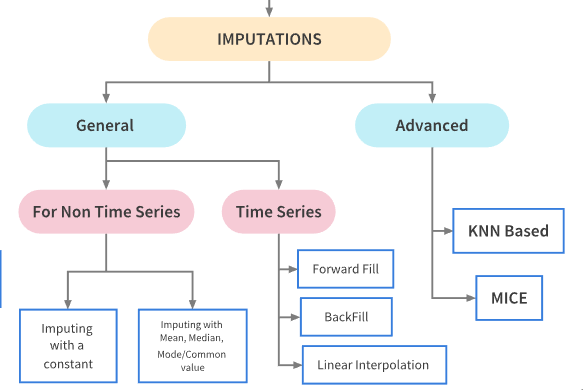

Imputation refers to replacing missing data with substituted values.There are a lot of ways in which the missing values can be imputed depending upon the nature of the problem and data. Dependng upon the nature of the problem, imputation techniques can be broadly they can be classified as follows:


**Basic Imputation Techniques**

Imputating with a constant value

Imputation using the statistics (mean, median or most frequent) of each column in which the missing values are located

**Using fillna()**

fillna() used to replace missing values (NaN) with a given value or any constant value

In [15]:
import pandas as pd
import numpy as np

d = {'First Score': [100, 90, np.nan, 95],
        'Second Score': [30, 45, 56, np.nan],
        'Third Score': [np.nan, 40, 80, 98]}
df = pd.DataFrame(d)
print(df)
df.fillna(0)

   First Score  Second Score  Third Score
0        100.0          30.0          NaN
1         90.0          45.0         40.0
2          NaN          56.0         80.0
3         95.0           NaN         98.0


,First Score,Second Score,Third Score
0,100.0,30.0,0.0
1,90.0,45.0,40.0
2,0.0,56.0,80.0
3,95.0,0.0,98.0


In [17]:
import pandas as pd
import numpy as np

d = {'First Score': ['Varshini', 'sai', np.nan, 'shiva'],
    }
df = pd.DataFrame(d)
print(df)
df.fillna('Janardhan')

  First Score
0    Varshini
1         sai
2         NaN
3       shiva


,First Score
0,Varshini
1,sai
2,Janardhan
3,shiva


In [30]:
import pandas as pd
import numpy as np
df = pd.read_csv("employees.csv")

In [31]:
df[10:25]

,First Name,Gender,Start Date,Last Login Time,Salary,Bonus %,Senior Management,Team
10,Louise,Female,8/12/1980,9:01 AM,63241,15.132,True,NaN
11,Julie,Female,10/26/1997,3:19 PM,102508,12.637,True,Legal
12,Brandon,Male,12/1/1980,1:08 AM,112807,17.492,True,Human Resources
13,Gary,Male,1/27/2008,11:40 PM,109831,5.831,False,Sales
14,Kimberly,Female,1/14/1999,7:13 AM,41426,14.543,True,Finance
15,Lillian,Female,6/5/2016,6:09 AM,59414,1.256,False,Product
16,Jeremy,Male,9/21/2010,5:56 AM,90370,7.369,False,Human Resources
17,Shawn,Male,12/7/1986,7:45 PM,111737,6.414,False,Product
18,Diana,Female,10/23/1981,10:27 AM,132940,19.082,False,Client Services
19,Donna,Female,7/22/2010,3:48 AM,81014,1.894,False,Product


In [25]:
df.isnull().sum()

First Name            67
Gender               145
Start Date             0
Last Login Time        0
Salary                 0
Bonus %                0
Senior Management     67
Team                  43
dtype: int64

In [27]:
df["Gender"].fillna('No Gender', inplace = True) 
df.isnull().sum()

First Name           67
Gender                0
Start Date            0
Last Login Time       0
Salary                0
Bonus %               0
Senior Management    67
Team                 43
dtype: int64

In [28]:
df[10:25]

,First Name,Gender,Start Date,Last Login Time,Salary,Bonus %,Senior Management,Team
10,Louise,Female,8/12/1980,9:01 AM,63241,15.132,True,NaN
11,Julie,Female,10/26/1997,3:19 PM,102508,12.637,True,Legal
12,Brandon,Male,12/1/1980,1:08 AM,112807,17.492,True,Human Resources
13,Gary,Male,1/27/2008,11:40 PM,109831,5.831,False,Sales
14,Kimberly,Female,1/14/1999,7:13 AM,41426,14.543,True,Finance
15,Lillian,Female,6/5/2016,6:09 AM,59414,1.256,False,Product
16,Jeremy,Male,9/21/2010,5:56 AM,90370,7.369,False,Human Resources
17,Shawn,Male,12/7/1986,7:45 PM,111737,6.414,False,Product
18,Diana,Female,10/23/1981,10:27 AM,132940,19.082,False,Client Services
19,Donna,Female,7/22/2010,3:48 AM,81014,1.894,False,Product


**Using replace()**

Use replace() function to replace NaN values with a specific value.

In [34]:
import pandas as pd
import numpy as np
df = pd.read_csv("employees.csv")
df[10:25]

,First Name,Gender,Start Date,Last Login Time,Salary,Bonus %,Senior Management,Team
10,Louise,Female,8/12/1980,9:01 AM,63241,15.132,True,NaN
11,Julie,Female,10/26/1997,3:19 PM,102508,12.637,True,Legal
12,Brandon,Male,12/1/1980,1:08 AM,112807,17.492,True,Human Resources
13,Gary,Male,1/27/2008,11:40 PM,109831,5.831,False,Sales
14,Kimberly,Female,1/14/1999,7:13 AM,41426,14.543,True,Finance
15,Lillian,Female,6/5/2016,6:09 AM,59414,1.256,False,Product
16,Jeremy,Male,9/21/2010,5:56 AM,90370,7.369,False,Human Resources
17,Shawn,Male,12/7/1986,7:45 PM,111737,6.414,False,Product
18,Diana,Female,10/23/1981,10:27 AM,132940,19.082,False,Client Services
19,Donna,Female,7/22/2010,3:48 AM,81014,1.894,False,Product


In [36]:
df = df.replace(to_replace=np.nan, value=-99)
print(df[10:25])

   First Name  Gender  Start Date Last Login Time  Salary  Bonus %  \
10     Louise  Female   8/12/1980         9:01 AM   63241   15.132   
11      Julie  Female  10/26/1997         3:19 PM  102508   12.637   
12    Brandon    Male   12/1/1980         1:08 AM  112807   17.492   
13       Gary    Male   1/27/2008        11:40 PM  109831    5.831   
14   Kimberly  Female   1/14/1999         7:13 AM   41426   14.543   
15    Lillian  Female    6/5/2016         6:09 AM   59414    1.256   
16     Jeremy    Male   9/21/2010         5:56 AM   90370    7.369   
17      Shawn    Male   12/7/1986         7:45 PM  111737    6.414   
18      Diana  Female  10/23/1981        10:27 AM  132940   19.082   
19      Donna  Female   7/22/2010         3:48 AM   81014    1.894   
20       Lois     -99   4/22/1995         7:18 PM   64714    4.934   
21    Matthew    Male    9/5/1995         2:12 AM  100612   13.645   
22     Joshua     -99    3/8/2012         1:58 AM   90816   18.816   
23        -99    Mal

**Impute using mean/median/mode**

In [41]:
import pandas as pd

# loading data set
data = pd.read_csv('employees.csv')

# display the data
print(data[10:25])

   First Name  Gender  Start Date Last Login Time    Salary  Bonus %  \
10     Louise  Female  08-12-1980         9:01 AM       NaN   15.132   
11      Julie  Female  10/26/1997         3:19 PM  102508.0   12.637   
12    Brandon    Male  12-01-1980         1:08 AM  112807.0   17.492   
13       Gary    Male   1/27/2008        11:40 PM  109831.0    5.831   
14   Kimberly  Female   1/14/1999         7:13 AM       NaN   14.543   
15    Lillian  Female  06-05-2016         6:09 AM   59414.0    1.256   
16     Jeremy    Male   9/21/2010         5:56 AM   90370.0    7.369   
17      Shawn    Male  12-07-1986         7:45 PM  111737.0    6.414   
18      Diana  Female  10/23/1981        10:27 AM  132940.0   19.082   
19      Donna  Female   7/22/2010         3:48 AM       NaN    1.894   
20       Lois     NaN   4/22/1995         7:18 PM   64714.0    4.934   
21    Matthew    Male  09-05-1995         2:12 AM  100612.0   13.645   
22     Joshua     NaN  03-08-2012         1:58 AM   90816.0   18

In [42]:
data.isnull().sum()

First Name            67
Gender               145
Start Date             0
Last Login Time        0
Salary                 7
Bonus %                4
Senior Management     67
Team                  43
dtype: int64

In [43]:
data['Salary'] = data['Salary'].fillna(data['Salary'].mean())

data['Bonus %'] = data['Bonus %'].fillna(data['Bonus %'].median())

data['Gender'] = data['Gender'].fillna(data['Gender'].mode())

In [44]:
data

,First Name,Gender,Start Date,Last Login Time,Salary,Bonus %,Senior Management,Team
0,Douglas,Male,08-06-1993,12:42 PM,97308.000000,6.945,True,Marketing
1,Thomas,Male,3/31/1996,6:53 AM,61933.000000,4.170,True,NaN
2,Maria,Female,4/23/1993,11:17 AM,130590.000000,11.858,False,Finance
3,Jerry,Male,03-04-2005,1:00 PM,90717.393756,9.340,True,Finance
4,Larry,Male,1/24/1998,4:47 PM,101004.000000,1.389,True,Client Services
...,...,...,...,...,...,...,...,...
995,Henry,NaN,11/23/2014,6:09 AM,132483.000000,16.655,False,Distribution
996,Phillip,Male,1/31/1984,6:30 AM,42392.000000,19.675,False,Finance
997,Russell,Male,5/20/2013,12:39 PM,96914.000000,1.421,False,Product
998,Larry,Male,4/20/2013,4:45 PM,60500.000000,11.985,False,Business Development


### **Imputations Techniques for Time Series Problems**

**Basic Imputation Techniques**

1. 'ffill' or 'pad' - Replace NaN s with last observed value

2. 'bfill' or 'backfill' - Replace NaN s with next observed value

3.  Linear interpolation method

**ffill**

In [56]:
city_day = pd.read_csv('city_day.csv',parse_dates=True,index_col='Date')
city_day1=city_day.copy(deep=True)
city_day.head()

,City,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,Xylene,AQI,AQI_Bucket
Date,,,,,,,,,,,,,,,
01-01-2015,Ahmedabad,NaN,NaN,0.92,18.22,17.15,NaN,0.92,27.64,133.36,0.00,0.02,0.00,NaN,NaN
02-01-2015,Ahmedabad,NaN,NaN,0.97,15.69,16.46,NaN,0.97,24.55,34.06,3.68,5.50,3.77,NaN,NaN
03-01-2015,Ahmedabad,NaN,NaN,17.40,19.30,29.70,NaN,17.40,29.07,30.70,6.80,16.40,2.25,NaN,NaN
04-01-2015,Ahmedabad,NaN,NaN,1.70,18.48,17.97,NaN,1.70,18.59,36.08,4.43,10.14,1.00,NaN,NaN
05-01-2015,Ahmedabad,NaN,NaN,22.10,21.42,37.76,NaN,22.10,39.33,39.31,7.01,18.89,2.78,NaN,NaN


In [57]:
city_day.isnull().sum()

City              0
PM2.5          4598
PM10          11140
NO             3582
NO2            3585
NOx            4185
NH3           10328
CO             2059
SO2            3854
O3             4022
Benzene        5623
Toluene        8041
Xylene        18109
AQI            4681
AQI_Bucket     4681
dtype: int64

In [58]:
city_day.fillna(method='ffill',inplace=True)
city_day['Xylene'][50:65]

C:\Users\venky\AppData\Local\Temp\ipykernel_19896\831388782.py:1: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  city_day.fillna(method='ffill',inplace=True)


Date
20-02-2015     7.48
21-02-2015    15.44
22-02-2015     8.47
23-02-2015    28.46
24-02-2015     6.05
25-02-2015     0.81
26-02-2015     0.81
27-02-2015     0.81
28-02-2015     0.81
01-03-2015     1.32
02-03-2015     0.22
03-03-2015     2.25
04-03-2015     1.55
05-03-2015     4.13
06-03-2015     4.13
Name: Xylene, dtype: float64

In [59]:
city_day['AQI'][20:30]

Date
21-01-2015      NaN
22-01-2015      NaN
23-01-2015      NaN
24-01-2015      NaN
25-01-2015      NaN
26-01-2015      NaN
27-01-2015      NaN
28-01-2015      NaN
29-01-2015    209.0
30-01-2015    328.0
Name: AQI, dtype: float64

In [60]:
city_day.fillna(method='bfill',inplace=True)
city_day['AQI'][20:30]

C:\Users\venky\AppData\Local\Temp\ipykernel_19896\4086047996.py:1: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  city_day.fillna(method='bfill',inplace=True)


Date
21-01-2015    209.0
22-01-2015    209.0
23-01-2015    209.0
24-01-2015    209.0
25-01-2015    209.0
26-01-2015    209.0
27-01-2015    209.0
28-01-2015    209.0
29-01-2015    209.0
30-01-2015    328.0
Name: AQI, dtype: float64

**Imputation using Linear Interpolation method**

Time series data has a lot of variations against time. Hence, imputing using backfill and forward fill isn't the best possible solution to address the missing value problem. A more apt alternative would be to use interpolation methods, where the values are filled with incrementing or decrementing values.

Linear interpolation is an imputation technique that assumes a linear relationship between data points and utilises non-missing values from adjacent data points to compute a value for a missing data point.


The interpolate() function fills missing values using interpolation techniques such as the linear method

In [61]:
city_day1['Xylene'][50:65]

Date
20-02-2015     7.48
21-02-2015    15.44
22-02-2015     8.47
23-02-2015    28.46
24-02-2015     6.05
25-02-2015     0.81
26-02-2015      NaN
27-02-2015      NaN
28-02-2015      NaN
01-03-2015     1.32
02-03-2015     0.22
03-03-2015     2.25
04-03-2015     1.55
05-03-2015     4.13
06-03-2015      NaN
Name: Xylene, dtype: float64

In [62]:
# Interpolate using the linear method
city_day1.interpolate(limit_direction="both",inplace=True)
city_day1['Xylene'][50:65]

C:\Users\venky\AppData\Local\Temp\ipykernel_19896\2164861449.py:2: FutureWarning: DataFrame.interpolate with object dtype is deprecated and will raise in a future version. Call obj.infer_objects(copy=False) before interpolating instead.
  city_day1.interpolate(limit_direction="both",inplace=True)


Date
20-02-2015     7.4800
21-02-2015    15.4400
22-02-2015     8.4700
23-02-2015    28.4600
24-02-2015     6.0500
25-02-2015     0.8100
26-02-2015     0.9375
27-02-2015     1.0650
28-02-2015     1.1925
01-03-2015     1.3200
02-03-2015     0.2200
03-03-2015     2.2500
04-03-2015     1.5500
05-03-2015     4.1300
06-03-2015     2.2600
Name: Xylene, dtype: float64

In [63]:
# Example

import pandas as pd
   
df = pd.DataFrame({"A": [12, 4, 5, None, 1], 
                   "B": [None, 2, 54, 3, None], 
                   "C": [20, 16, None, 3, 8], 
                   "D": [14, 3, None, None, 6]})  
print(df)

      A     B     C     D
0  12.0   NaN  20.0  14.0
1   4.0   2.0  16.0   3.0
2   5.0  54.0   NaN   NaN
3   NaN   3.0   3.0   NaN
4   1.0   NaN   8.0   6.0


In [64]:
df.interpolate(method ='linear', limit_direction ='forward')

,A,B,C,D
0,12.0,NaN,20.0,14.0
1,4.0,2.0,16.0,3.0
2,5.0,54.0,9.5,4.0
3,3.0,3.0,3.0,5.0
4,1.0,3.0,8.0,6.0


### **Algorithms which handle missing values**

Some algprithms like XGBoost and LightGBM can handle missing values without any preprocessing, by supplying relevant parameters.

**XGBOOST**

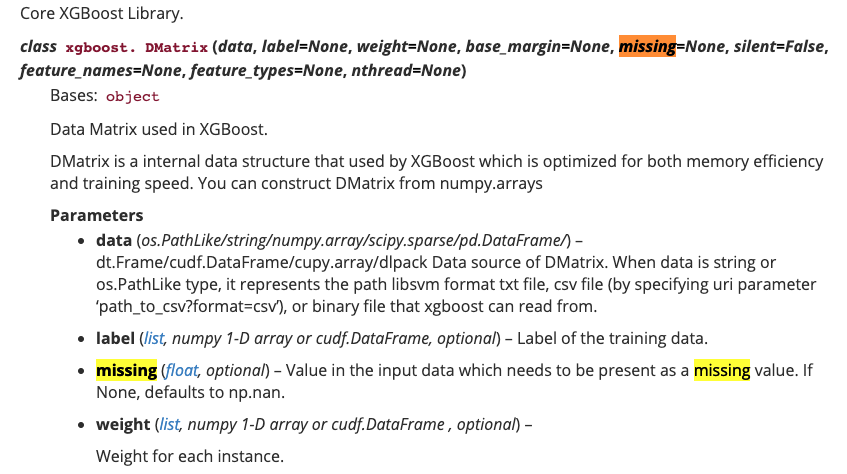

**LightGBm**

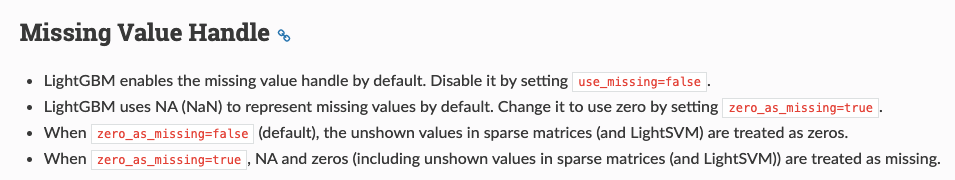